# Transformer for Multimodal Stock Forecasting
Implementation notebook for *Adaptive Portfolio Management in Volatile Markets with Multiplex Attention Transformers and Deep Reinforcement Learning*.

Code for **PyTorch** implementation of the Transformer proposed in our paper, trained to predict multi-step stock price trajectories from:
1. **Technical indicators** (OHLCV-derived)
2. **News‑sentiment embeddings** (from FinBERT)
3. **Macroeconomic features**

The model outputs \(H\)-step forecasts that later serve as inputs to the downstream RL trading agent.

In [1]:
!pip install -U torch torchvision torchaudio --quiet
!pip install -U transformers datasets peft --quiet
!pip install -U wandb --quiet
!pip install pytorch_lightning --quiet
!pip install pytorch_forecasting --quiet
!pip install darts --quiet
!pip install pandas_market_calendars --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201

In [2]:
import darts
import math, os, random, json, itertools, warnings, datetime as dt, typing as typ
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
import wandb
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Running on', device)


Running on cuda


In [3]:
# some hyperparameters
WINDOW_SIZE = 30  # T
HORIZON_SIZE = 5  # H
BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-2
ALPHA         = 0.9      # weight for MSE vs BCE
GRAD_CLIP     = 2.0

# feature dimensions
TECH_DIM = 10
SENT_DIM = 1
MACRO_DIM = 3

In [4]:
# # init wandb
# wandb_api = "8736734cbf8541aa58ecb7f6776b57754d1c10d5"
# wandb.login(key=wandb_api)
# wandb.init(
#     project="transformer price forecast",
#     config={
#         "window": WINDOW_SIZE,
#         "horizon": HORIZON_SIZE,
#         "lr": 1e-4,
#     }
# )

## Data Processing

In [5]:
import pandas as pd, numpy as np
import pandas as pd, numpy as np, torch
from torch.utils.data import Dataset, DataLoader


def load_tensor(csv_path: str, feature_cols: list[str],
                tickers=None, dates=None):
    df = pd.read_csv(csv_path, parse_dates=['date'])

    if tickers is None: tickers = sorted(df['ticker'].unique())
    if dates   is None: dates   = sorted(df['date'].unique())

    df = (df.query('ticker in @tickers and date in @dates')
            .sort_values(['date', 'ticker']))

    mats = []
    for feat in feature_cols:
        mat = (df.pivot(index='date', columns='ticker', values=feat)
                 .reindex(index=dates, columns=tickers)
                 .astype('float32')
                 .fillna(0.0)   # replace missing with 0, try avoiding nan
                 .values)
        mats.append(mat[..., None])

    return np.concatenate(mats, axis=2), tickers, dates

class MultiCSVWindowDataset(Dataset):
    """
    Each sample = (x_stock, x_sent, x_macro, y)
    Shapes:
      x_* : [window, F]   (one ticker, consecutive dates)
      y   : [horizon, 1]  (open/close/high/low for next horizon days)
    """
    def __init__(self, npz_path: str, window: int = WINDOW_SIZE, horizon: int = HORIZON_SIZE):
        data = np.load(npz_path)
        self.stock  = data['tech']    # [D, N, F1]
        self.sent   = data['sent']    # [D, N, F2]
        self.macro  = data['macro']   # [D, N, F3]
        self.labels = data['price']   # [D, N, 1]

        self.T = window
        self.H = horizon
        self.D = self.stock.shape[0] - window - horizon
        self.N = self.stock.shape[1]

    def __len__(self):
        return self.D * self.N            # all (ticker, start‑time) pairs

    def __getitem__(self, idx):
        t0 = idx % self.D                 # time start
        k  = idx // self.D                # ticker index

        x_stock = self.stock [t0:t0+self.T, k, :]
        x_sent  = self.sent  [t0:t0+self.T, k, :]
        x_macro = self.macro[t0:t0+self.T, k, :]
        y = self.labels[t0+self.T:t0+self.T+self.H, k, :]   # horizon×4

        # previous day's true close:
        # this is for calculating accuracy only
        prev_close = self.labels[t0+self.T-1, k, 0]     # scalar

        # historical closes
        hist_close = self.labels[t0 : t0+self.T, k, 0]   # [T]

        return (torch.tensor(x_stock),
                torch.tensor(x_sent),
                torch.tensor(x_macro),
                torch.tensor(y),
                torch.tensor(prev_close),
                torch.tensor(hist_close))


# feature scaling (min‑max to 0‑1)
class MinMaxScaler:
    def __init__(self, feature_range=(0, 1)):
        self.min_ = None
        self.max_ = None
        self.data_min_ = None
        self.data_max_ = None
        self.feature_range = feature_range

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.data_min_ = X.min(axis=0)
        self.data_max_ = X.max(axis=0)
        self.min_ = self.feature_range[0]
        self.max_ = self.feature_range[1]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        scale = (self.max_ - self.min_) / (self.data_max_ - self.data_min_)
        X_scaled = self.min_ + (X - self.data_min_) * scale
        return X_scaled

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X_scaled):
        X_scaled = np.asarray(X_scaled, dtype=float)
        scale = (self.max_ - self.min_) / (self.data_max_ - self.data_min_)
        X_original = self.data_min_ + (X_scaled - self.min_) / scale
        return X_original


class DataPreprocessor():
    def __init__(self):
        self.scalers = {"tech": [], "sent": [], "macro": [], "label": []}

    def add_scalers(self, df_type: str, new_scalers: list):
        if df_type in self.scalers:
            self.scalers[df_type].extend(new_scalers)
        else:
            raise KeyError("dataframe type not supported!")

    def fit_transform(self, df_type: str, X):
        """
        X: numpy array of shape (days, stocks, features)
        """
        X_scaled = np.empty_like(X)
        days, stocks, features = X.shape

        for i in range(features):
            feature_data = X[:, :, i].reshape(-1, 1)  # (days * stocks, 1)
            X_scaled_feature = self.scalers[df_type][i].fit_transform(feature_data)
            X_scaled[:, :, i] = X_scaled_feature.reshape(days, stocks)

        return X_scaled

    def transform(self, df_type: str, X):
        """
        X: numpy array of shape (days, stocks, features)
        """
        X_scaled = np.empty_like(X)
        days, stocks, features = X.shape

        for i in range(features):
            feature_data = X[:, :, i].reshape(-1, 1)
            X_scaled_feature = self.scalers[df_type][i].transform(feature_data)
            X_scaled[:, :, i] = X_scaled_feature.reshape(days, stocks)

        return X_scaled

    def inverse_transform(self, df_type: str, X_scaled):
        """
        X: numpy array of shape (days, stocks, features)
        """
        X_orig = np.empty_like(X_scaled)
        days, stocks, features = X_scaled.shape

        for i in range(features):
            feature_data = X_scaled[:, :, i].reshape(-1, 1)
            X_orig_feature = self.scalers[df_type][i].inverse_transform(feature_data)
            X_orig[:, :, i] = X_orig_feature.reshape(days, stocks)

        return X_orig

    def process(self, tech_csv: str, sent_csv: str,
                           macro_csv: str, label_csv: str,
                           train_mode: bool, dataset_out_path: str):
        """
        Preprocesses tech, sent, macro, and label datasets.

        Args:
            tech_csv, sent_csv, macro_csv, label_csv: csv file paths
            train_mode: True for scalers to fit-transform, False for scalers to transform only
            dataset_out_path: file path to save output MultiCSVWindowDataset

        Returns:
            dataset: a MultiCSVWindowDataset
            loader: a DataLoader
        """

        tech_cols = ['volume','macd','boll_ub','boll_lb','rsi_30','cci_30',
                      'dx_30','close_30_sma','close_60_sma','vix', 'close',
                     'open','high', 'low']
        sent_cols  = ['sentiment']
        macro_cols = ['fedfunds','sp500','sector']
        label_cols = ['close']

        # build aligned tensors
        tech, tickers, dates  = load_tensor(tech_csv,  tech_cols) # tech.shape = (# dates, # tickers, # features)
        sent, _, _ = load_tensor(sent_csv,  sent_cols,  tickers, dates)
        macro, _, _  = load_tensor(macro_csv, macro_cols, tickers, dates)
        # print(macro.shape, type(macro), macro)

        #  build 4‑price cube (Date × Ticker)
        lbl_df = pd.read_csv(label_csv, parse_dates=['date'])
        lbl_df = (
            lbl_df.query('ticker in @tickers and date in @dates')
                  .sort_values(['date', 'ticker'])
        )

        label_mats = []
        for col in label_cols:         # ['close']
            mat = (lbl_df.pivot(index='date', columns='ticker', values=col)
                          .reindex(index=dates, columns=tickers)     # enforce exact order
                          .astype('float32')
                          .values)                                   # (D, N)
            label_mats.append(mat[..., None])                        # add 1‑len feature axis

        label = np.concatenate(label_mats, axis=2)         # (D, N, 1)
        # print(label.shape, type(label), label)
        self.add_scalers("tech", [MinMaxScaler() for col in tech_cols])
        self.add_scalers("sent", [MinMaxScaler() for col in sent_cols])
        self.add_scalers("macro", [MinMaxScaler() for col in macro_cols])
        self.add_scalers("label", [MinMaxScaler() for col in label_cols])
        if train_mode:
            tech_scaled = self.fit_transform(df_type = "tech", X = tech)
            sent_scaled = self.fit_transform(df_type = "sent", X = sent)
            macro_scaled = self.fit_transform(df_type = "macro", X = macro)
            label_scaled = self.fit_transform(df_type = "label", X = label)
        else:
            tech_scaled = self.transform(df_type = "tech", X = tech)
            sent_scaled = self.transform(df_type = "sent", X = sent)
            macro_scaled = self.transform(df_type = "macro", X = macro)
            label_scaled = self.transform(df_type = "label", X = label)
        # print(label_scaled.shape, label_scaled)


        np.savez_compressed(
            dataset_out_path,
            tech=tech_scaled, sent=sent_scaled,
            macro=macro_scaled, price=label)


        dataset = MultiCSVWindowDataset(dataset_out_path, window=WINDOW_SIZE, horizon=HORIZON_SIZE)
        loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        return dataset, loader




In [6]:
# get train data
data_preprocessor = DataPreprocessor()
dataset, loader = data_preprocessor.process(tech_csv="train_stock.csv",
                                            sent_csv="train_sentiment.csv",
                                            macro_csv="train_macro.csv",
                                            label_csv="train_stock.csv",
                                            train_mode=True,
                                            dataset_out_path="aligned_data_train.npz")

# right after building train_dataset, check shape
x_s, x_se, x_m, y, close, hist_close = dataset[0]
print(y)
print(close)
print("First train window shapes:", x_s.shape, x_se.shape, x_m.shape, y.shape)
print(" First target (raw):", data_preprocessor.inverse_transform("label", y.unsqueeze(0)).round())
print(" First features peek:", x_s[-1, :3].round())  # last time‐step stock features


# get val data
dataset, loader = data_preprocessor.process(tech_csv="val_stock.csv",
                                            sent_csv="val_sentiment.csv",
                                            macro_csv="val_macro.csv",
                                            label_csv="val_stock.csv",
                                            train_mode=False,
                                            dataset_out_path="aligned_data_val.npz")


# get test data
dataset, loader = data_preprocessor.process(tech_csv="test_stock.csv",
                                            sent_csv="test_sentiment.csv",
                                            macro_csv="test_macro.csv",
                                            label_csv="test_stock.csv",
                                            train_mode=False,
                                            dataset_out_path="aligned_data_test.npz")






tensor([[2.8447],
        [2.8399],
        [2.7277],
        [2.7445],
        [2.6166]])
tensor(2.9841)
First train window shapes: torch.Size([30, 14]) torch.Size([30, 1]) torch.Size([30, 3]) torch.Size([5, 1])
 First target (raw): [[[1220.]
  [1218.]
  [1170.]
  [1177.]
  [1122.]]]
 First features peek: tensor([0., 1., 0.])


## Multiplex Attention Block

In [7]:

# class MultiplexAttention(nn.Module):
#     """Applies self‑attention independently to three modality streams and concatenates the results."""

#     def __init__(self, dim: int, num_heads: int):
#         super().__init__()
#         self.dim = dim
#         self.num_heads = num_heads
#         self.attn_stock = nn.MultiheadAttention(dim, num_heads, batch_first=True)
#         self.attn_sent  = nn.MultiheadAttention(dim, num_heads, batch_first=True)
#         self.attn_macro = nn.MultiheadAttention(dim, num_heads, batch_first=True)
#         # projection after concat of 3*dim back to dim
#         self.out_proj   = nn.Linear(3*dim, dim)
#         #self.norm = nn.LayerNorm(dim)



#     def forward(self, x_stock, x_sent, x_macro, key_padding_mask=None):
#         seq_len = x_stock.size(1)
#         attn_mask = torch.triu(torch.ones(seq_len, seq_len) * float('-inf'), diagonal=1).to(x_stock.device)

#         # each input: [B, T, D]
#         a_stock, _ = self.attn_stock(x_stock, x_stock, x_stock,
#                                      key_padding_mask=key_padding_mask,
#                                      attn_mask=attn_mask)
#         a_sent,  _ = self.attn_sent(x_sent, x_sent, x_sent,
#                                     key_padding_mask=key_padding_mask,
#                                     attn_mask=attn_mask)
#         a_macro, _ = self.attn_macro(x_macro, x_macro, x_macro,
#                                      key_padding_mask=key_padding_mask,
#                                      attn_mask=attn_mask)
#         # concat on last dim
#         cat = torch.cat([a_stock, a_sent, a_macro], dim=-1)
#         out = self.out_proj(cat)
#         #return self.norm(out)
#         return out


## Transformer Forecasting Model

In [8]:

# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model: int, max_len: int = 5000):
#         super().__init__()
#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
#         pe = pe.unsqueeze(0)  # [1, max_len, d_model]
#         self.register_buffer('pe', pe)
#     def forward(self, x):
#         x = x + self.pe[:, :x.size(1), :]
#         return x

# class MultiplexTransformerForecaster(nn.Module):
#     def __init__(self,
#                  dim: int = 128,
#                  num_heads: int = 4,
#                  num_layers: int = 4,
#                  horizon: int = HORIZON_SIZE,
#                  dropout: float = 0.2,
#                  tech_dim:  int = TECH_DIM,
#                  sent_dim:  int = SENT_DIM,
#                  macro_dim: int = MACRO_DIM,
#                  window:    int = WINDOW_SIZE):
#         super().__init__()
#         self.horizon = horizon
#         self.window  = window
#         self.attn_norm = nn.LayerNorm(dim)

#         # modality‑specific projections
#         self.embed_stock = nn.Linear(tech_dim,  dim)
#         self.embed_sent  = nn.Linear(sent_dim,  dim)
#         self.embed_macro = nn.Linear(macro_dim, dim)

#         self.pos_enc = PositionalEncoding(dim)

#         blocks = []
#         for _ in range(num_layers):
#             blocks.append(MultiplexAttention(dim, num_heads))
#             blocks.append(nn.Sequential(
#                 nn.LayerNorm(dim),
#                 nn.Linear(dim, dim*4), nn.GELU(),
#                 nn.Dropout(dropout),
#                 nn.Linear(dim*4, dim)
#             ))
#         self.layers = nn.ModuleList(blocks)

#         # prediction head: produce horizon × 4 prices, not just horizon
#         self.pred_head = nn.Sequential(
#             nn.LayerNorm(dim),
#             nn.Flatten(start_dim=1),                      # [B, window*dim]
#             nn.Linear(dim * window, horizon * 4)
#         )



#     def forward(self, x_stock, x_sent, x_macro):          # [B, T, F*]
#         s = self.embed_stock(x_stock)
#         t = self.embed_sent(x_sent)
#         m = self.embed_macro(x_macro)

#         s, t, m = map(self.pos_enc, (s, t, m))

#         for blk in self.layers:
#             if isinstance(blk, MultiplexAttention):
#                 residual = s
#                 s = t = m = blk(s, t, m)
#                 s = s + residual
#                 s = self.attn_norm(s)
#             else:                         # feed‑forward
#                 s = s + blk(s)
#                 t = m = s

#         # price prediction
#         price_logits = self.pred_head(s)        # [B, horizon*4]
#         price_pred   = price_logits.view(-1, self.horizon, 4)

#         return price_pred


In [9]:
# # try this one instead
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
#         super().__init__()
#         self.dropout = nn.Dropout(dropout)
#         # create constant 'pe' matrix with values dependent on pos and i
#         pe = torch.zeros((max_len, d_model))
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(
#             torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
#         )
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
#         pe = pe.unsqueeze(0)  # shape [1, max_len, d_model]
#         self.register_buffer('pe', pe)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         # x shape: [batch_size, seq_len, d_model]
#         x = x + self.pe[:, :x.size(1)]
#         return self.dropout(x)

# class ImprovedTransformerForecaster(nn.Module):
#     def __init__(
#         self,
#         tech_dim: int,
#         sent_dim: int,
#         macro_dim: int,
#         d_model: int = 256,
#         n_heads: int = 4,
#         n_layers: int = 4,
#         window: int = WINDOW_SIZE,
#         dropout: float = 0.1,
#     ):
#         super().__init__()
#         self.window = window
#         total_dim = tech_dim + sent_dim + macro_dim
#         self.input_proj = nn.Linear(total_dim, d_model)
#         self.pos_enc    = PositionalEncoding(d_model, dropout, max_len=window)
#         enc_layer = nn.TransformerEncoderLayer(
#             d_model=d_model,
#             nhead=n_heads,
#             dim_feedforward=d_model * 4,
#             dropout=dropout,
#             activation='gelu'
#         )
#         self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
#         self.head = nn.Sequential(
#             nn.LayerNorm(d_model),
#             nn.Linear(d_model, 1)
#         )

#     def forward(
#         self,
#         x_tech: torch.Tensor,
#         x_sent: torch.Tensor,
#         x_macro: torch.Tensor
#     ) -> torch.Tensor:
#         # x_* shapes: [B, T, F]
#         x = torch.cat([x_tech, x_sent, x_macro], dim=-1)  # [B, T, total_dim]
#         x = self.input_proj(x)                           # [B, T, d_model]
#         x = self.pos_enc(x)                              # [B, T, d_model]
#         x = x.transpose(0, 1)                            # [T, B, d_model]
#         x = self.transformer(x)                          # [T, B, d_model]
#         x = x.transpose(0, 1)                            # [B, T, d_model]
#         return self.head(x)                              # [B, T, 1]



### Inject LoRA Adapters

In [10]:

# Uncomment to add LoRA adapters if `peft` is installed in environment
# from peft import get_peft_model, LoraConfig, TaskType
# lora_cfg = LoraConfig(
#     task_type=TaskType.FEATURE_EXTRACTION,
#     target_modules=['q_proj', 'k_proj', 'v_proj'],
#     r=8, lora_alpha=32, lora_dropout=0.05)
# model = MultiplexTransformerForecaster().to(device)
# model = get_peft_model(model, lora_cfg)


## Training Loop

In [11]:
# # def train_epoch(model, loader, optimizer, scaler,
# #                 mse_loss, bce_loss,
# #                 alpha=0.8, grad_clip=2.0):
# #     model.train()
# #     total_loss = 0.0
# #     total_correct = 0
# #     total_samples = 0
# #     scaling_factor = 1    # scale BCE to match MSE magnitude
# #     eps = 1e-6  # define once

# #     # move min/max tensors once
# #     pm = torch.tensor(price_min, dtype=torch.float32, device=device)
# #     pM = torch.tensor(price_max, dtype=torch.float32, device=device)

# #     for x_stock, x_sent, x_macro, y, prev_close, hist_close in loader:
# #         # to device & reshape
# #         x_stock, x_sent, x_macro = [t.to(device) for t in (x_stock, x_sent, x_macro)]
# #         y          = y.to(device).squeeze(-1)     # [B, H]
# #         prev_close = prev_close.to(device)        # [B]

# #         # forward
# #         y_hat = model(x_stock, x_sent, x_macro)   # [B, H, 1]

# #         # regression loss
# #         Lmse = mse_loss(y_hat, y.unsqueeze(-1))   # [B,H,1]

# #         hist_close = hist_close.to(device)

# #         # compute returns over the window
# #         # simple pct‐change:
# #         rets = (hist_close[:, 1:] - hist_close[:, :-1]) \
# #                  / (hist_close[:, :-1] + eps)      # [B, T-1]
# #         vol = rets.std(dim=1)                    # [B], sample volatility

# #         # forward & regression as before
# #         y_hat = model(x_stock, x_sent, x_macro)  # [B,H,1]
# #         y_denorm = y_hat * (pM - pm) + pm        # [B,H,1]
# #         pred0 = y_denorm[:,0,0]                  # [B]

# #         # normalized logit
# #         logit = (pred0 - prev_close) / (vol + eps)  # [B]

# #         # now BCE on this standardized logit
# #         true_up = (y[:,0] > prev_close).float()
# #         Lbce    = bce_loss(logit, true_up)

# #         # 4) combined loss & backward
# #         loss = alpha * Lmse + (1 - alpha) * (scaling_factor * Lbce)
# #         optimizer.zero_grad()
# #         scaler.scale(loss).backward()
# #         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
# #         scaler.step(optimizer)
# #         scaler.update()

# #         # 5) metrics
# #         B = y.size(0)
# #         total_samples  += B
# #         total_loss     += loss.item() * B
# #         preds = (logit > 0).float()
# #         total_correct += (preds == true_up).sum().item()
# #         #print(f"MSE={Lmse.item():.1f}  BCE={Lbce.item():.4f}  scaled BCE={(scaling_factor*Lbce).item():.1f}")


# #     return total_loss / total_samples, total_correct / total_samples


# # def evaluate_epoch(model, loader, mse_loss, bce_loss, current_epoch):
# #     model.eval()
# #     total_loss = 0.0
# #     total_samples = 0
# #     total_correct = 0

# #     pm = torch.tensor(price_min, dtype=torch.float32, device=device)
# #     pM = torch.tensor(price_max, dtype=torch.float32, device=device)

# #     logged = False

# #     with torch.no_grad():
# #         for x_stock, x_sent, x_macro, y, prev_close, hist_close in loader:
# #             x_stock, x_sent, x_macro = [t.to(device) for t in (x_stock, x_sent, x_macro)]
# #             y          = y.to(device).squeeze(-1)
# #             prev_close = prev_close.to(device)

# #             # forward
# #             y_hat = model(x_stock, x_sent, x_macro)   # [B,H,1]

# #             # regression loss
# #             Lmse = mse_loss(y_hat, y.unsqueeze(-1))

# #             # build logit
# #             y_denorm = y_hat * (pM - pm) + pm
# #             logit    = (y_denorm[:, 0, 0] - prev_close)
# #             true_up  = (y[:, 0] > prev_close).float()
# #             Lbce     = bce_loss(logit, true_up)

# #             # optionally track combined loss or just MSE
# #             loss = Lmse + Lbce  # or loss = Lmse

# #             B = y.size(0)
# #             total_samples += B
# #             total_loss    += loss.item() * B

# #             preds = (logit > 0).float()
# #             total_correct += (preds == true_up).sum().item()

# #     return total_loss / total_samples, total_correct / total_samples




# def train_epoch():
#     model.train()
#     total_loss = total_correct = total_samples = 0
#     eps = 1e-6
#     pm = torch.tensor(price_min, dtype=torch.float32, device=device)
#     pM = torch.tensor(price_max, dtype=torch.float32, device=device)

#     for x_s, x_t, x_m, y, prev_close, hist in train_loader:
#         x_s, x_t, x_m = [t.to(device) for t in (x_s, x_t, x_m)]
#         y          = y.to(device).squeeze(-1)  # [B, H]
#         prev_close = prev_close.to(device)
#         hist       = hist.to(device)

#         y_hat = model(x_s, x_t, x_m)           # [B, H, 1]
#         Lmse  = mse_loss(y_hat, y.unsqueeze(-1))

#         rets = (hist[:,1:] - hist[:,:-1]) / (hist[:,:-1] + eps)
#         vol  = rets.std(dim=1)

#         y_denorm = y_hat * (pM - pm) + pm      # [B,H,1]
#         pred0    = y_denorm[:,0,0]
#         logit    = (pred0 - prev_close) / (vol + eps)
#         true_up  = (y[:,0] > prev_close).float()
#         Lbce     = bce_loss(logit, true_up)

#         loss = ALPHA * Lmse + (1-ALPHA)*Lbce
#         optimizer.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
#         optimizer.step()
#         scheduler.step()

#         B = y.size(0)
#         total_samples += B
#         total_loss    += loss.item() * B
#         total_correct += ((logit>0).float() == true_up).sum().item()

#     return total_loss/total_samples, total_correct/total_samples


# def evaluate_epoch(epoch):
#     model.eval()
#     total_loss = total_correct = total_samples = 0
#     pm = torch.tensor(price_min, dtype=torch.float32, device=device)
#     pM = torch.tensor(price_max, dtype=torch.float32, device=device)

#     with torch.no_grad():
#         for x_s, x_t, x_m, y, prev_close, hist in val_loader:
#             x_s, x_t, x_m = [t.to(device) for t in (x_s, x_t, x_m)]
#             y          = y.to(device).squeeze(-1)
#             prev_close = prev_close.to(device)

#             y_hat = model(x_s, x_t, x_m)
#             Lmse  = mse_loss(y_hat, y.unsqueeze(-1))

#             y_denorm = y_hat * (pM - pm) + pm
#             logit    = (y_denorm[:,0,0] - prev_close)
#             true_up  = (y[:,0] > prev_close).float()
#             Lbce     = bce_loss(logit, true_up)

#             loss = Lmse + Lbce
#             B = y.size(0)
#             total_samples += B
#             total_loss    += loss.item() * B
#             total_correct += ((logit>0).float() == true_up).sum().item()


#     return total_loss/total_samples, total_correct/total_samples

In [12]:
# train_ds = MultiCSVWindowDataset('aligned_data_train.npz', WINDOW_SIZE, HORIZON_SIZE)
# val_ds   = MultiCSVWindowDataset('aligned_data_val.npz',   WINDOW_SIZE, HORIZON_SIZE)
# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
# val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = ImprovedTransformerForecaster(
#     tech_dim=train_ds.stock.shape[-1],
#     sent_dim=train_ds.sent.shape[-1],
#     macro_dim=train_ds.macro.shape[-1]
# ).to(device)
# optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# scheduler = torch.optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=LEARNING_RATE,
#     total_steps=NUM_EPOCHS * len(train_loader),
#     pct_start=0.1,
#     anneal_strategy='cos'
# )
# mse_loss = nn.MSELoss()
# bce_loss = nn.BCEWithLogitsLoss()



# all_up = []
# for _,_,_,y,prev,hist_prev in val_loader:
#     y, prev = y.squeeze(-1).to(device), prev.to(device)
#     all_up.append((y[:,0] > prev).long())
# all_up = torch.cat(all_up)
# print("Up fraction:", all_up.float().mean().item())

# for epoch in range(NUM_EPOCHS):
#     train_loss, train_acc = train_epoch()
#     val_loss, val_acc = evaluate_epoch(epoch)
#     print(f'Epoch {epoch+1}: train MSE = {train_loss:.4f}, val MSE = {val_loss:.4f}, train acc = {train_acc:.4f}, val acc = {val_acc:.4f}')


# Cross-Validation

In [13]:
# from sklearn.model_selection import KFold
# from torch.utils.data import DataLoader, Subset
# import numpy as np
# import torch.nn as nn
# import torch.optim as optim

In [14]:


# def cross_validate(dataset, param_grid, folds=3, epochs=10):
#     results = []
#     kf = KFold(n_splits=folds, shuffle=True, random_state=42)

#     for params in param_grid:
#         fold_losses = []
#         for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
#             train_subset = Subset(dataset, train_idx)
#             val_subset = Subset(dataset, val_idx)

#             train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, drop_last=True)
#             val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, drop_last=False)

#             model = MultiplexTransformerForecaster(
#                 tech_dim=TECH_DIM,
#                 sent_dim=SENT_DIM,
#                 macro_dim=MACRO_DIM,
#                 window=WINDOW_SIZE,
#                 horizon=HORIZON_SIZE,
#                 **params
#             ).to(device)

#             optimizer = optim.AdamW(model.parameters(), lr=params.get('lr', 1e-4), weight_decay=1e-2)
#             scaler = torch.cuda.amp.GradScaler()
#             loss_fn = nn.MSELoss()

#             for epoch in range(epochs):
#                 train_epoch(model, train_loader, optimizer, scaler, loss_fn)

#             val_loss = evaluate_epoch(model, val_loader, loss_fn)
#             fold_losses.append(val_loss)

#         avg_loss = np.mean(fold_losses)
#         results.append((params, avg_loss))
#         print(f"Params: {params}, Avg Val Loss: {avg_loss:.4f}")

#     best_params = min(results, key=lambda x: x[1])[0]
#     print(f"\nBest Hyperparameters: {best_params}")
#     return best_params, results

In [15]:
# param_grid = [
#     {"dropout": 0.1, "dim": 128, "num_heads":4},
#     {"dropout": 0.2, "dim": 256, "num_heads":8},
# ]

In [16]:
# best_params, results = cross_validate(dataset, param_grid, folds=3, epochs=10)


# TFT Forecasting

In [17]:
# TFT forecasting with Darts for multi-stock data using covariates



# get data and constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import TFTModel
from darts.utils.likelihood_models import QuantileRegression
from darts.dataprocessing.transformers import Scaler
import warnings
import pandas_market_calendars as mcal

warnings.filterwarnings('ignore')

# hyperparameters and data paths
NPZ_TRAIN         = 'aligned_data_train.npz'
NPZ_VAL           = 'aligned_data_val.npz'
NPZ_TEST          = 'aligned_data_test.npz'  # your test file
INPUT_CHUNK_LENGTH = 30
FORECAST_HORIZON   = 1
BATCH_SIZE         = 32
N_EPOCHS           = 100
RANDOM_STATE       = 42

# load data
train_npz = np.load(NPZ_TRAIN)
val_npz   = np.load(NPZ_VAL)
test_npz  = np.load(NPZ_TEST)

days_train, num_tickers, _ = train_npz['price'].shape
days_val                   =   val_npz['price'].shape[0]
days_test                  =  test_npz['price'].shape[0]

# market calendar
nyse = mcal.get_calendar("NYSE")
schedule_train = nyse.schedule(
    start_date="2009-01-01",
    end_date="2020-06-30"
)
schedule_val   = nyse.schedule(
    start_date="2020-07-01",
    end_date="2024-03-31"
)
schedule_test  = nyse.schedule(
    start_date="2024-04-01",
    end_date="2025-03-31"
)

dates_train = schedule_train.index
dates_val   = schedule_val.index
dates_test  = schedule_test.index

# sanity check lengths
assert len(dates_train) == days_train
assert len(dates_val)   == days_val
assert len(dates_test)  == days_test

# prepare column names for covariates
tech_n  = train_npz['tech'].shape[2]
sent_n  = train_npz['sent'].shape[2]
macro_n = train_npz['macro'].shape[2]

cov_cols = (
    [f"tech_{i}"  for i in range(tech_n)]
  + [f"sent_{i}"  for i in range(sent_n)]
  + [f"macro_{i}" for i in range(macro_n)]
)

# business-day freq from NYSE
from pandas.tseries.offsets import CustomBusinessDay
holidays = nyse.holidays().holidays
freq     = CustomBusinessDay(holidays=holidays)

# Build the four lists for train/val/test
train_target_list   = []
train_past_cov_list = []
val_target_list     = []
val_past_cov_list   = []
test_target_list    = []
test_past_cov_list  = []

for t in range(num_tickers):
    # TRAIN price
    price_tr = train_npz['price'][:, t, 0]
    ts_tr    = TimeSeries.from_times_and_values(
                   dates_train, price_tr,
                   freq=freq,
                   fill_missing_dates=False
               )
    train_target_list.append(ts_tr)

    # TRAIN covariates
    cov_tr = np.concatenate([
        train_npz['tech'][:,  t, :],
        train_npz['sent'][:,  t, :],
        train_npz['macro'][:, t, :]
    ], axis=1)
    df_cov_tr = pd.DataFrame(cov_tr, index=dates_train, columns=cov_cols)
    ts_cov_tr = TimeSeries.from_dataframe(
                    df_cov_tr, freq=freq, fill_missing_dates=False
                )
    train_past_cov_list.append(ts_cov_tr)

    # VAL price
    price_v  = val_npz['price'][:, t, 0]
    ts_val   = TimeSeries.from_times_and_values(
                   dates_val, price_v,
                   freq=freq,
                   fill_missing_dates=False
               )
    val_target_list.append(ts_val)

    # VAL covariates
    cov_v = np.concatenate([
        val_npz['tech'][:,  t, :],
        val_npz['sent'][:,  t, :],
        val_npz['macro'][:, t, :]
    ], axis=1)
    df_cov_v = pd.DataFrame(cov_v, index=dates_val, columns=cov_cols)
    ts_cov_v = TimeSeries.from_dataframe(
                   df_cov_v, freq=freq, fill_missing_dates=False
               )
    val_past_cov_list.append(ts_cov_v)

    # TEST price
    price_te = test_npz['price'][:, t, 0]
    ts_te    = TimeSeries.from_times_and_values(
                   dates_test, price_te,
                   freq=freq,
                   fill_missing_dates=False
               )
    test_target_list.append(ts_te)

    # TEST covariates
    cov_te = np.concatenate([
        test_npz['tech'][:,  t, :],
        test_npz['sent'][:,  t, :],
        test_npz['macro'][:, t, :]
    ], axis=1)
    df_cov_te = pd.DataFrame(cov_te, index=dates_test, columns=cov_cols)
    ts_cov_te = TimeSeries.from_dataframe(
                    df_cov_te, freq=freq, fill_missing_dates=False
                )
    test_past_cov_list.append(ts_cov_te)





In [25]:
# add early stopping
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

# define stopper
my_stopper = EarlyStopping(
    monitor="val_loss",    # the metric to watch
    patience=5,           # wait this many epochs with no improvement
    min_delta=0.001,       # only count an “improvement” if loss drops ≥ this
    mode="min"             # we want val_loss to go down
)



In [26]:
# instantiate and fit TFTModel

from torch.nn import L1Loss, SmoothL1Loss

# experiment with different quantiles
#quantiles = np.arange(0.01, 1.0, 0.01).tolist()
quantiles = [0.01, 0.05, 0.1, 0.15, 0.2,0.25, 0.3, 0.4, 0.5,
             0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99,]
#quantiles = [0.25, 0.5, 0.75]

likelihood = QuantileRegression(quantiles=quantiles)
model = TFTModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=FORECAST_HORIZON,
    hidden_size=64,
    lstm_layers=2,
    num_attention_heads=4,
    dropout=0.2,
    batch_size=BATCH_SIZE,
    n_epochs=100,
    add_relative_index=True,
    add_encoders=None,
    #likelihood=likelihood,
    likelihood=None,
    random_state=RANDOM_STATE,
    use_static_covariates=False,
    force_reset=True,
    #loss_fn=L1Loss(),
    loss_fn=SmoothL1Loss(beta=1.0),
    pl_trainer_kwargs={
        'accelerator': 'gpu',
        'gradient_clip_val': 0.1,
        'enable_progress_bar': True,
        'max_epochs': N_EPOCHS,
        'check_val_every_n_epoch': 1,
        'log_every_n_steps': 10,
        'logger': True,
        'callbacks': [my_stopper],
    }
)
model.fit(
    series=train_target_list,
    past_covariates=train_past_cov_list,
    val_series=val_target_list,
    val_past_covariates=val_past_cov_list,
    verbose=True
)



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | SmoothL1Loss                     | 0      | train
1  | train_criterion                   | SmoothL1Loss                     | 0      | train
2  | val_criterion                     | SmoothL1Loss                     | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection               

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

TFTModel(output_chunk_shift=0, hidden_size=64, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, loss_fn=SmoothL1Loss(), likelihood=None, norm_type=LayerNorm, use_static_covariates=False, input_chunk_length=30, output_chunk_length=1, batch_size=32, n_epochs=100, add_encoders=None, random_state=42, force_reset=True, pl_trainer_kwargs={'accelerator': 'gpu', 'gradient_clip_val': 0.1, 'enable_progress_bar': True, 'max_epochs': 100, 'check_val_every_n_epoch': 1, 'log_every_n_steps': 10, 'logger': True, 'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x791dd83347d0>]})

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


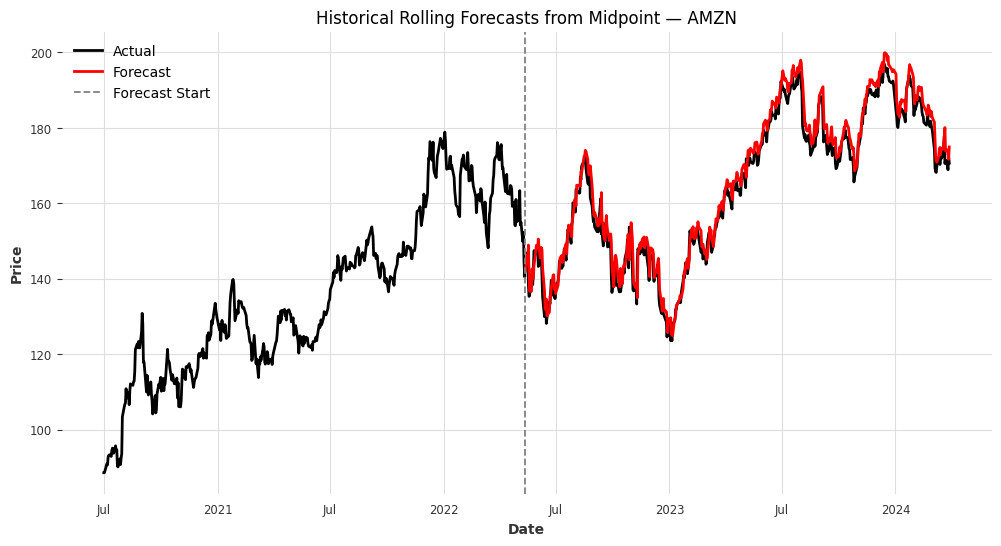

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for AMZN: MAPE=1.73%, SMAPE=1.71%, MAE=2.8009, MSE=12.09
Directional Accuracy for AMZN: 49.15%



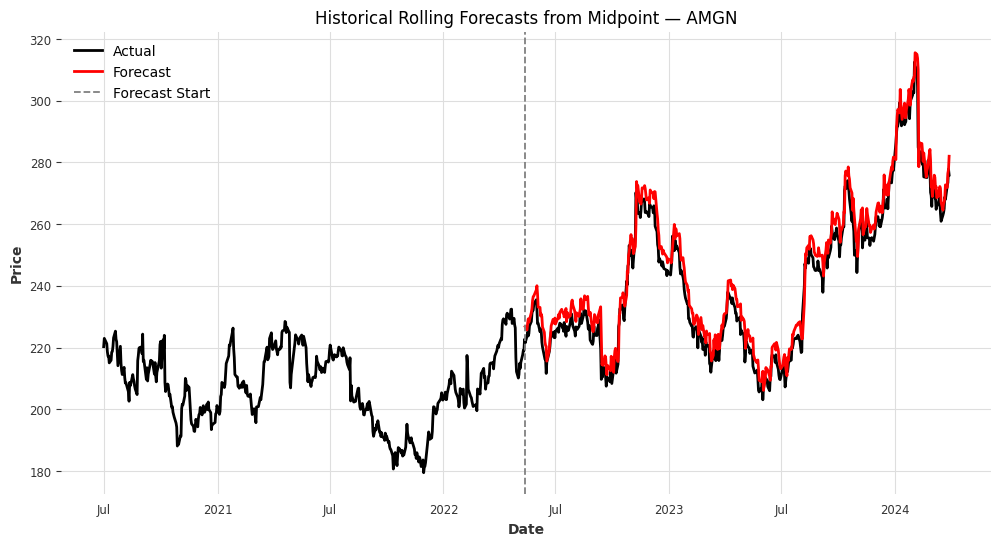

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for AMGN: MAPE=1.85%, SMAPE=1.83%, MAE=4.4335, MSE=26.81
Directional Accuracy for AMGN: 48.94%



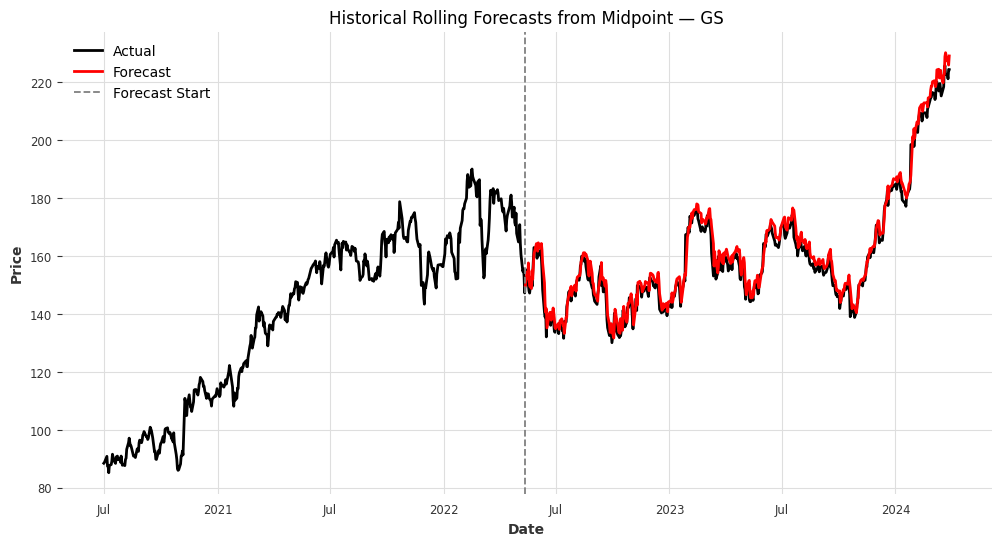

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for GS: MAPE=1.74%, SMAPE=1.72%, MAE=2.7559, MSE=11.96
Directional Accuracy for GS: 52.77%



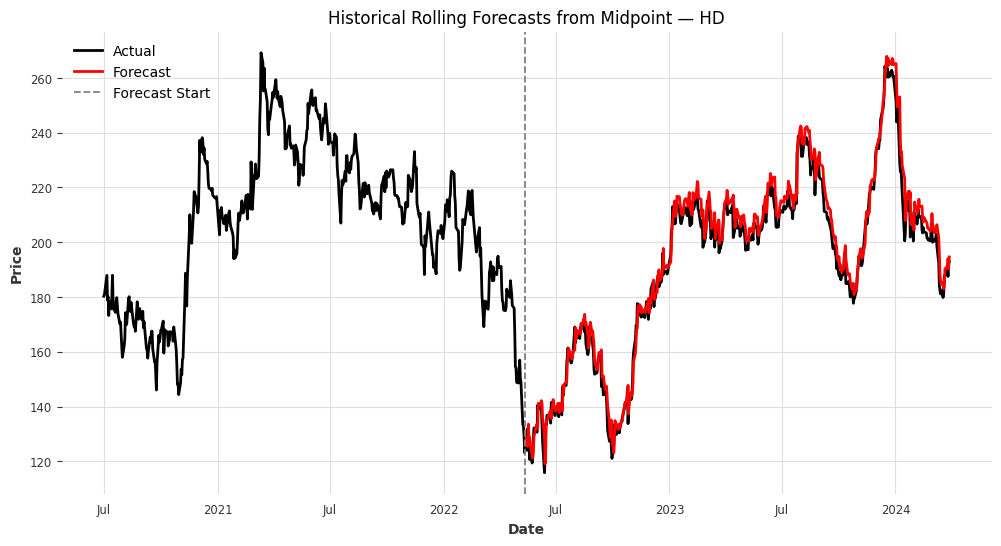

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for HD: MAPE=2.12%, SMAPE=2.09%, MAE=3.9608, MSE=26.55
Directional Accuracy for HD: 50.43%



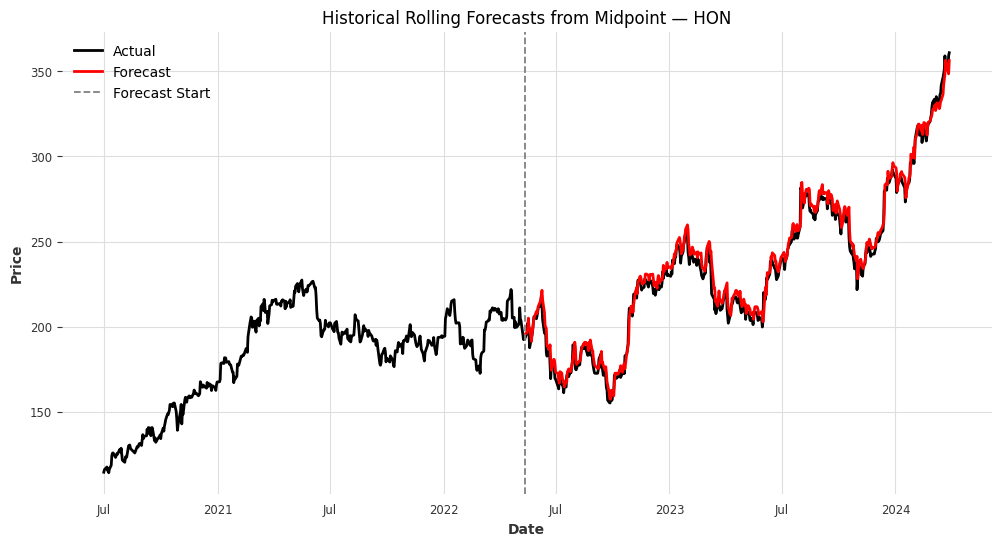

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for HON: MAPE=1.88%, SMAPE=1.86%, MAE=4.2458, MSE=29.15
Directional Accuracy for HON: 55.32%



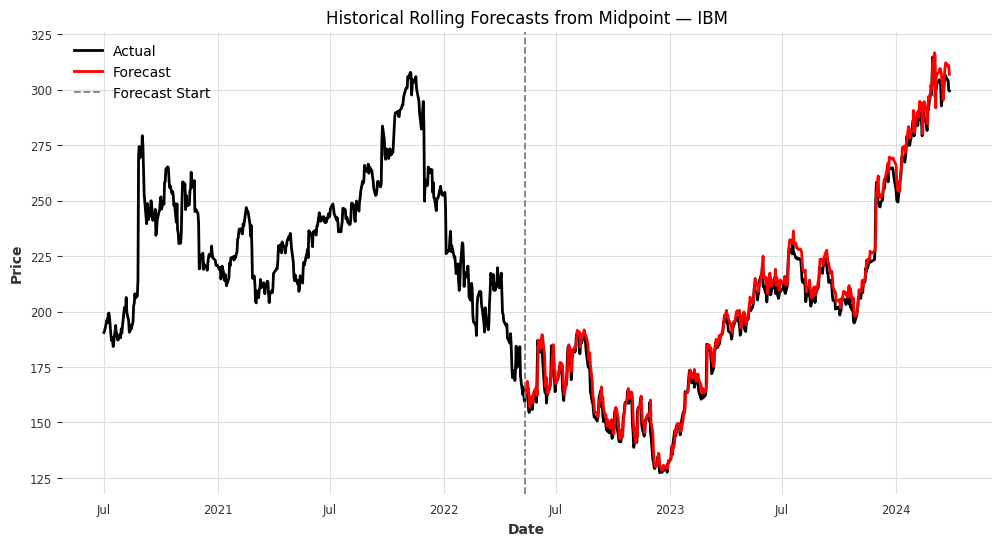

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for IBM: MAPE=2.09%, SMAPE=2.07%, MAE=4.0488, MSE=26.37
Directional Accuracy for IBM: 55.96%



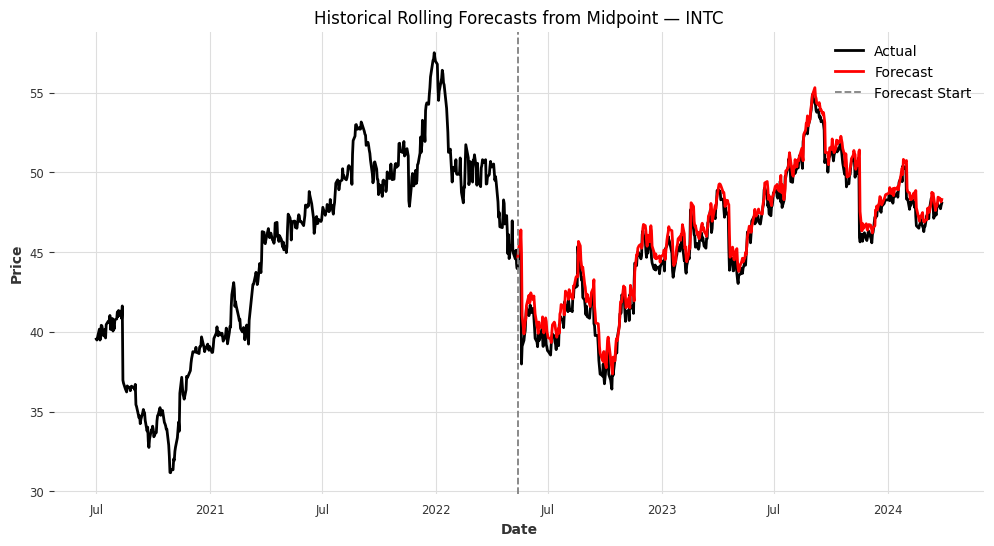

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for INTC: MAPE=1.53%, SMAPE=1.51%, MAE=0.6760, MSE=0.83
Directional Accuracy for INTC: 50.64%



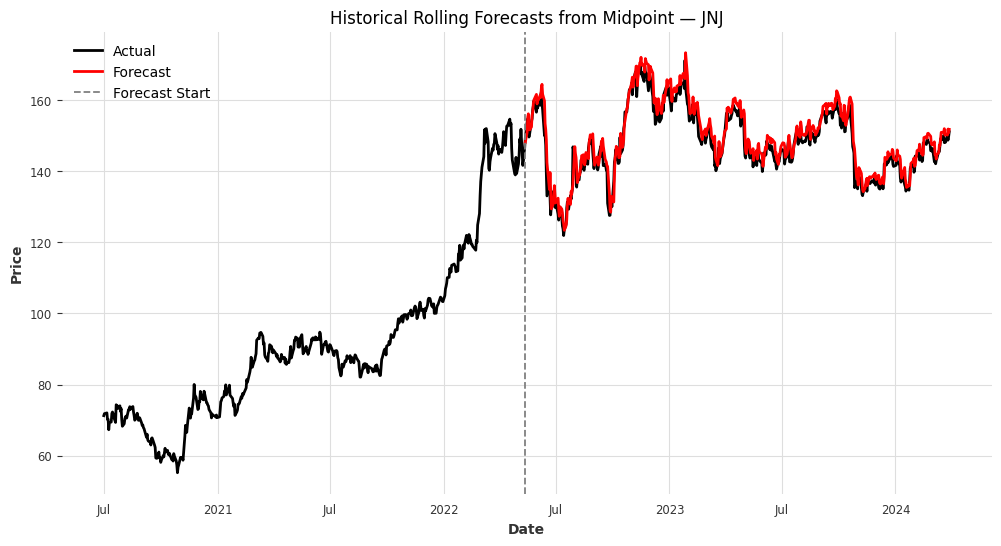

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for JNJ: MAPE=1.65%, SMAPE=1.63%, MAE=2.4250, MSE=9.74
Directional Accuracy for JNJ: 50.43%



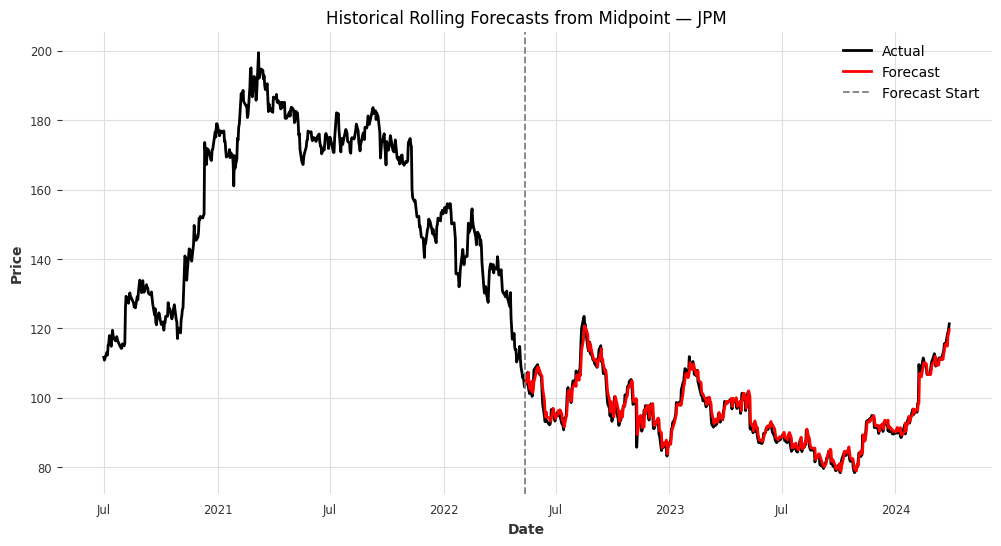

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for JPM: MAPE=1.56%, SMAPE=1.55%, MAE=1.5019, MSE=4.31
Directional Accuracy for JPM: 51.28%



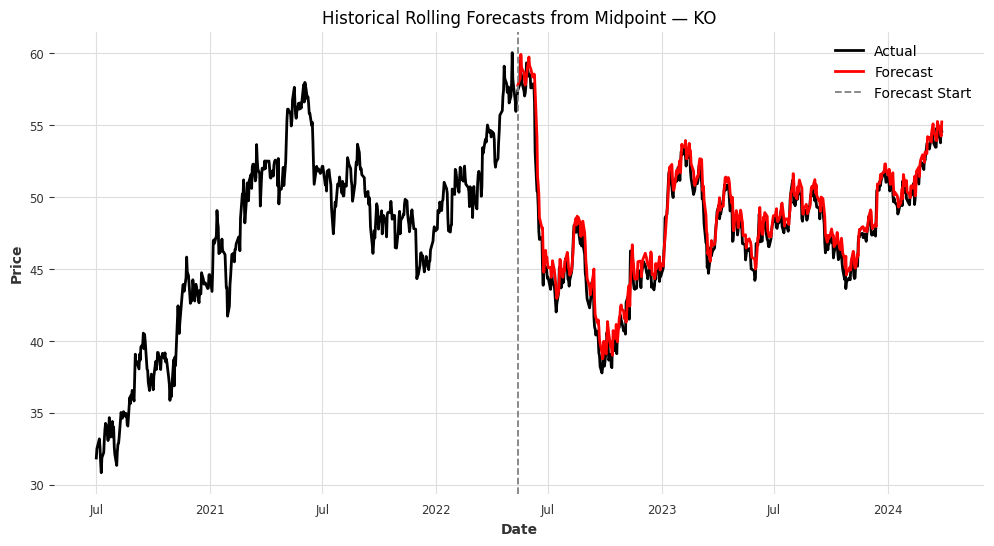

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for KO: MAPE=1.65%, SMAPE=1.63%, MAE=0.7717, MSE=0.94
Directional Accuracy for KO: 53.40%



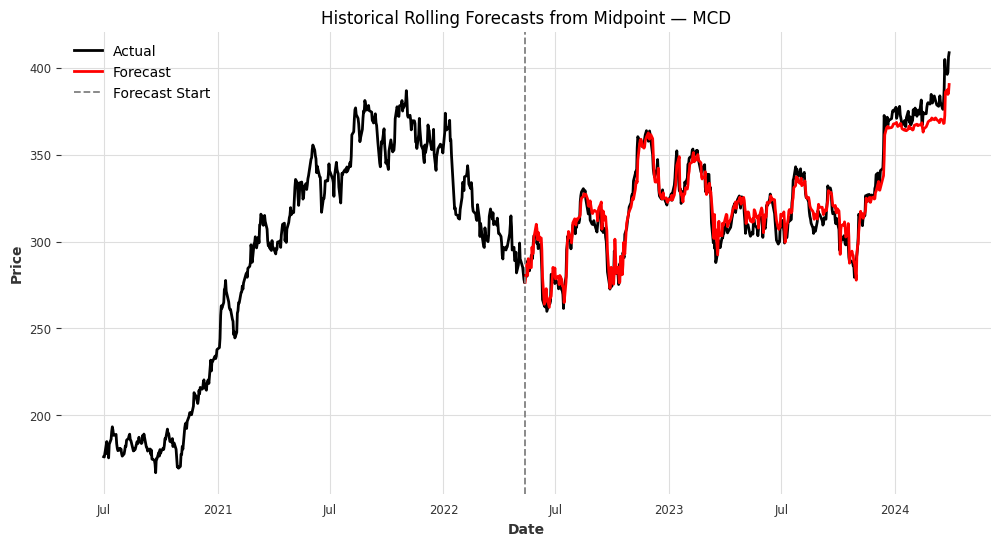

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for MCD: MAPE=1.76%, SMAPE=1.76%, MAE=5.7161, MSE=51.12
Directional Accuracy for MCD: 52.34%



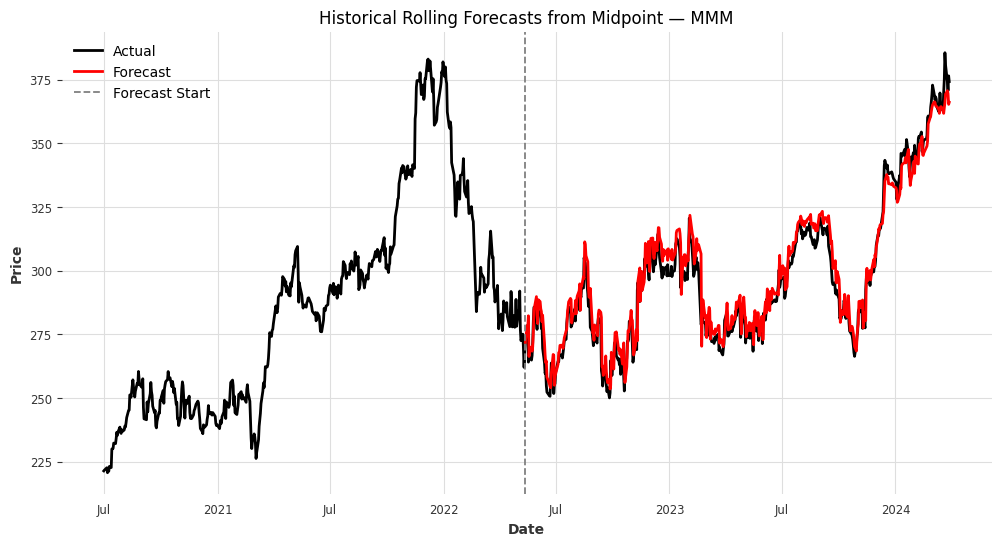

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for MMM: MAPE=1.63%, SMAPE=1.62%, MAE=4.8065, MSE=36.74
Directional Accuracy for MMM: 48.72%



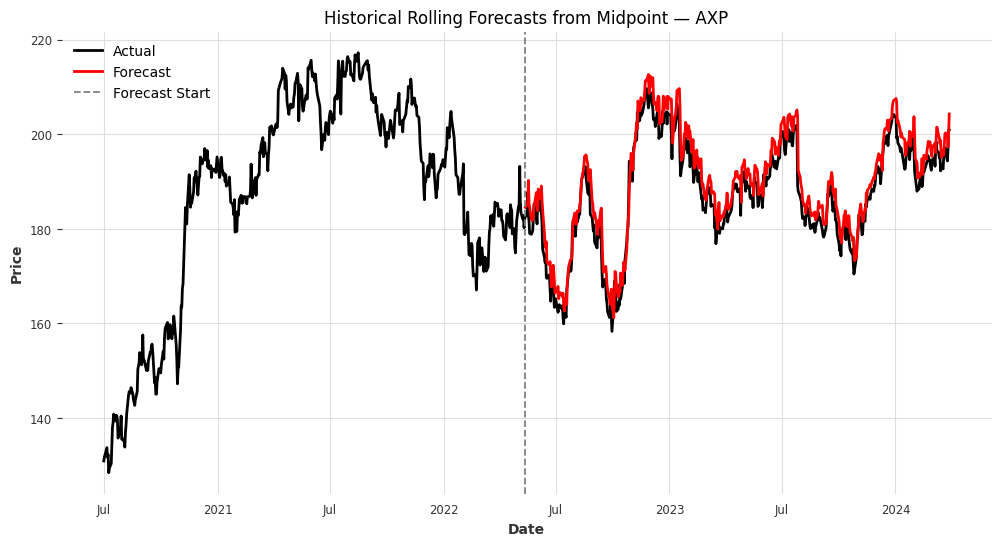

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for AXP: MAPE=1.62%, SMAPE=1.60%, MAE=3.0083, MSE=13.10
Directional Accuracy for AXP: 50.43%



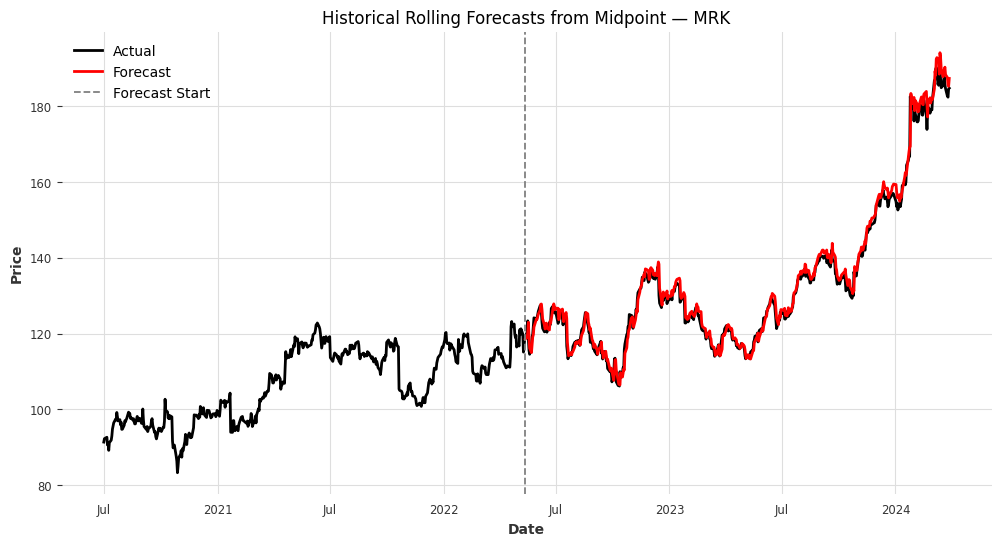

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for MRK: MAPE=1.16%, SMAPE=1.16%, MAE=1.5758, MSE=4.46
Directional Accuracy for MRK: 53.19%



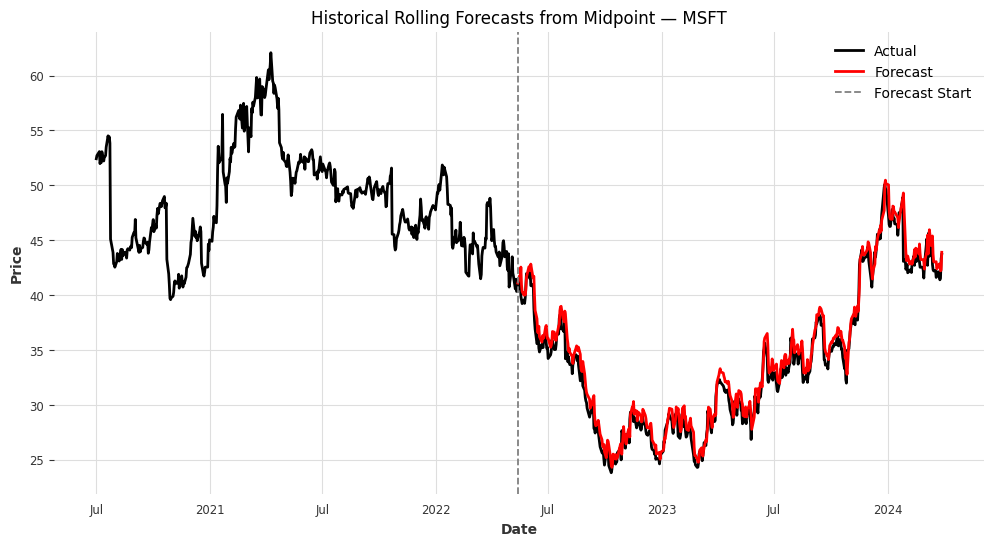

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for MSFT: MAPE=2.66%, SMAPE=2.62%, MAE=0.8799, MSE=1.24
Directional Accuracy for MSFT: 53.83%



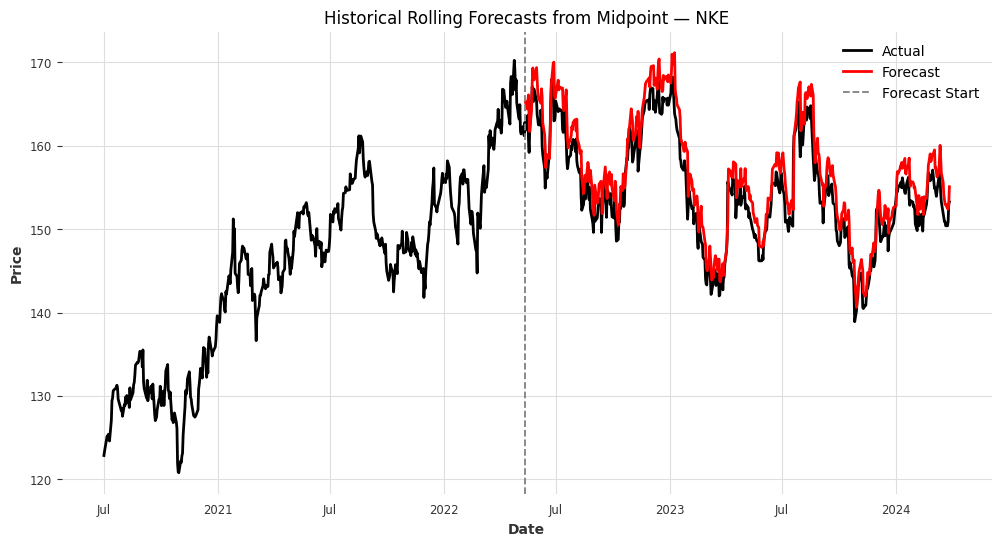

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for NKE: MAPE=1.51%, SMAPE=1.49%, MAE=2.3291, MSE=7.51
Directional Accuracy for NKE: 55.11%



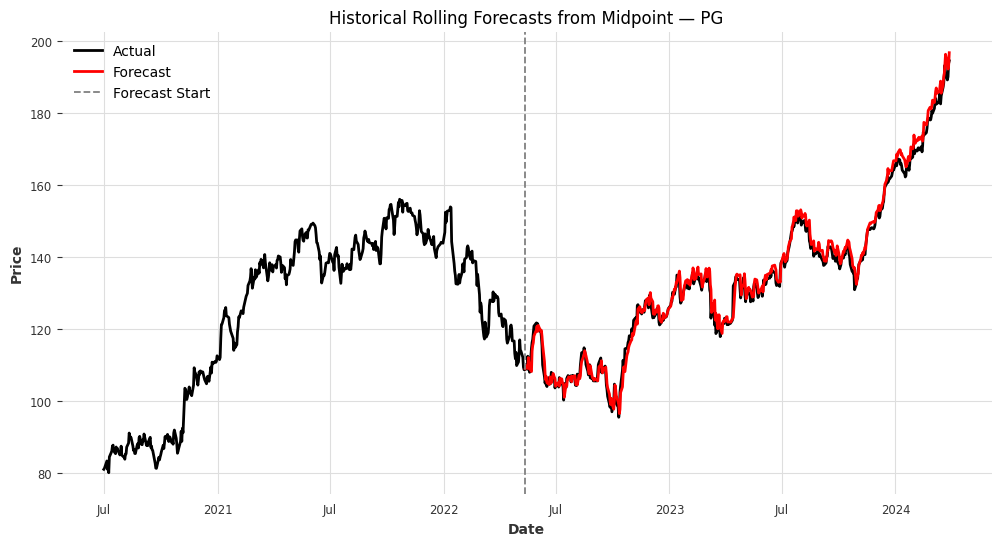

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for PG: MAPE=1.33%, SMAPE=1.32%, MAE=1.7511, MSE=4.97
Directional Accuracy for PG: 48.94%



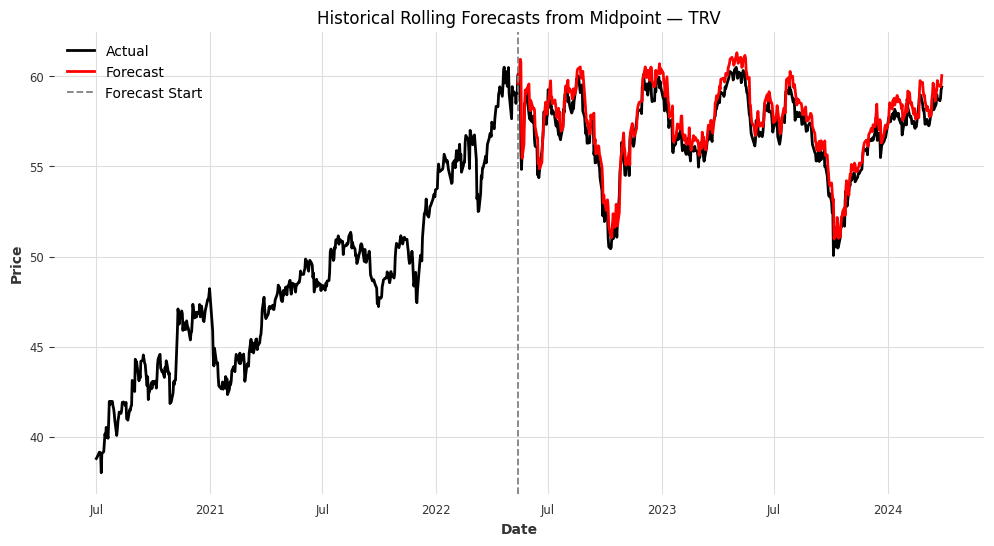

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for TRV: MAPE=1.24%, SMAPE=1.23%, MAE=0.7045, MSE=0.73
Directional Accuracy for TRV: 49.36%



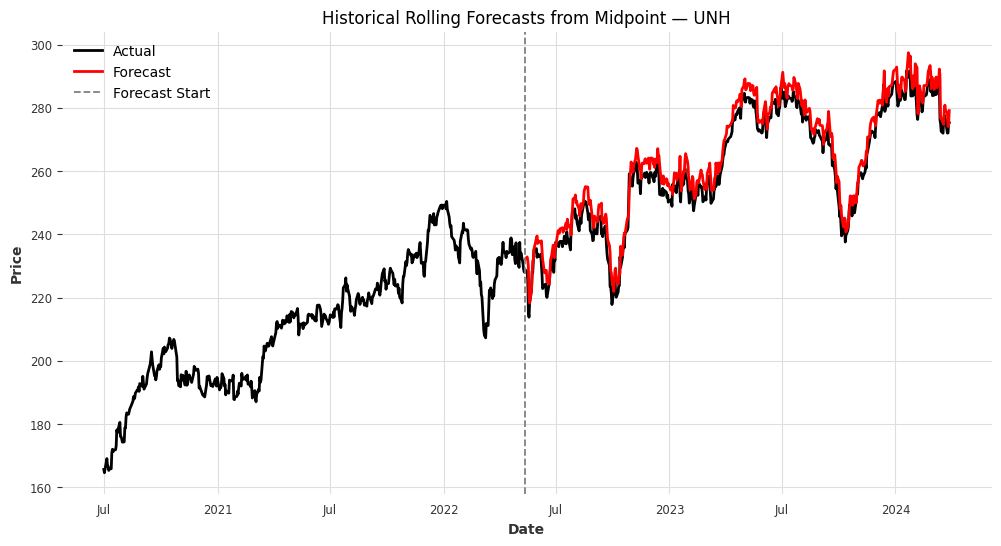

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for UNH: MAPE=1.51%, SMAPE=1.49%, MAE=3.8777, MSE=20.76
Directional Accuracy for UNH: 52.77%



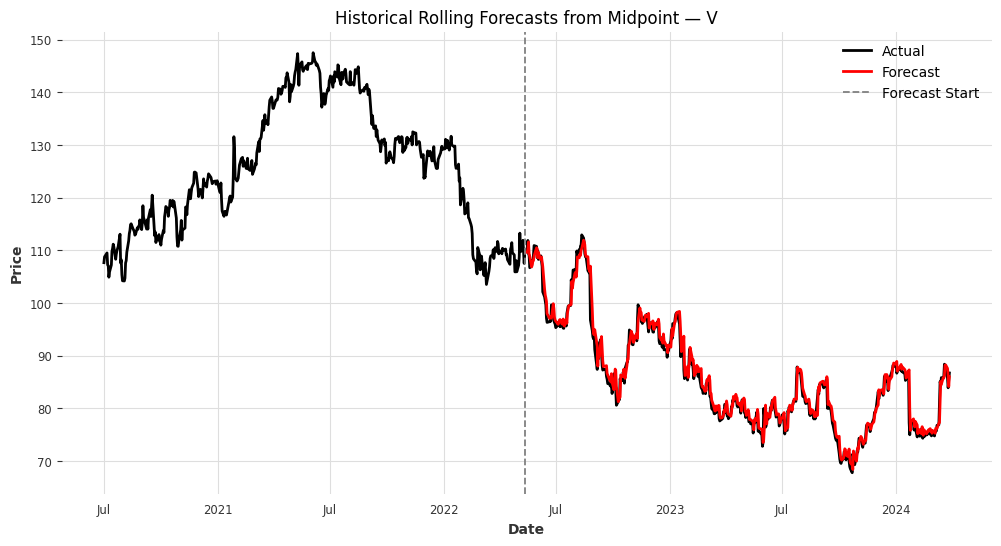

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for V: MAPE=1.39%, SMAPE=1.38%, MAE=1.1903, MSE=2.80
Directional Accuracy for V: 47.87%



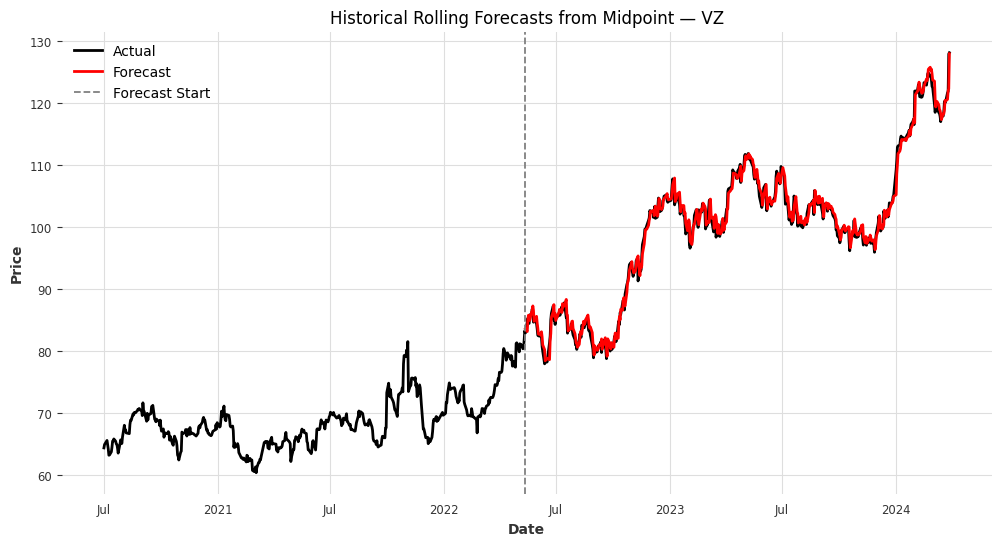

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for VZ: MAPE=0.95%, SMAPE=0.95%, MAE=0.9352, MSE=1.54
Directional Accuracy for VZ: 52.77%



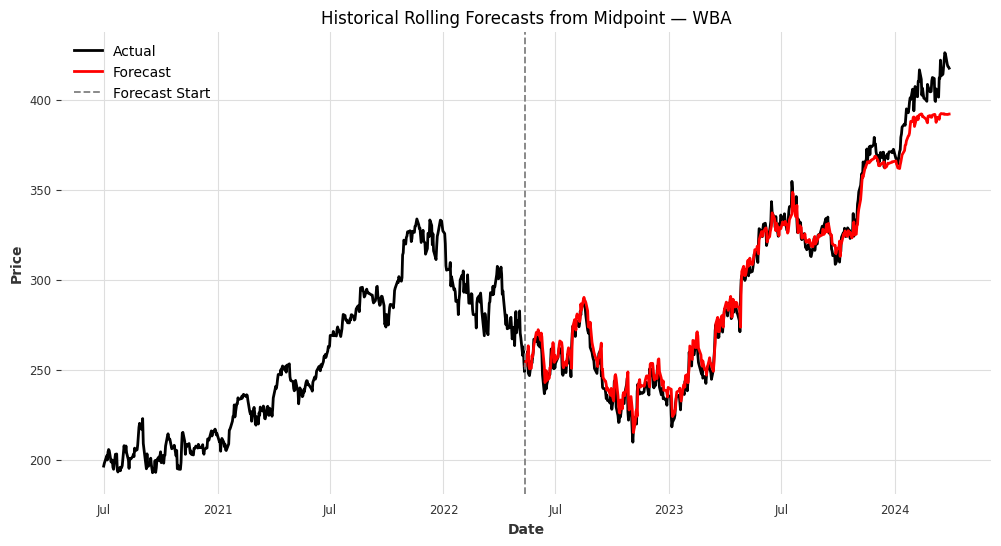

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for WBA: MAPE=2.05%, SMAPE=2.05%, MAE=6.3270, MSE=73.31
Directional Accuracy for WBA: 53.62%



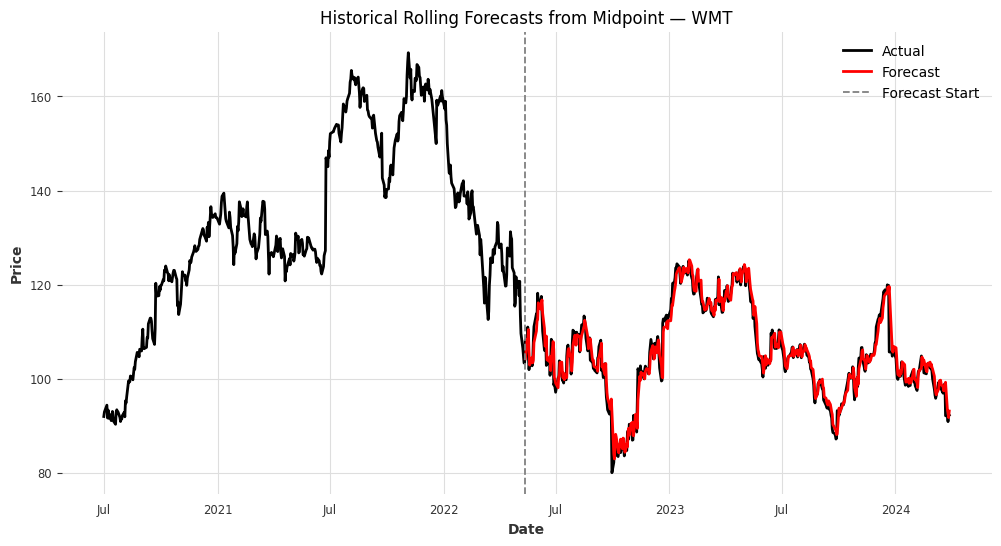

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for WMT: MAPE=1.60%, SMAPE=1.59%, MAE=1.6619, MSE=5.22
Directional Accuracy for WMT: 49.15%



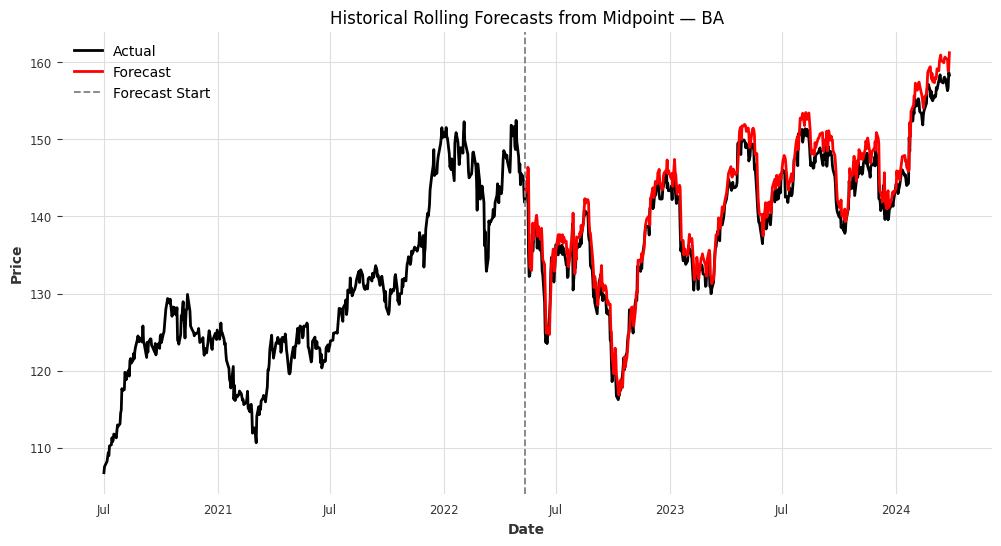

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for BA: MAPE=1.30%, SMAPE=1.29%, MAE=1.8296, MSE=4.99
Directional Accuracy for BA: 51.06%



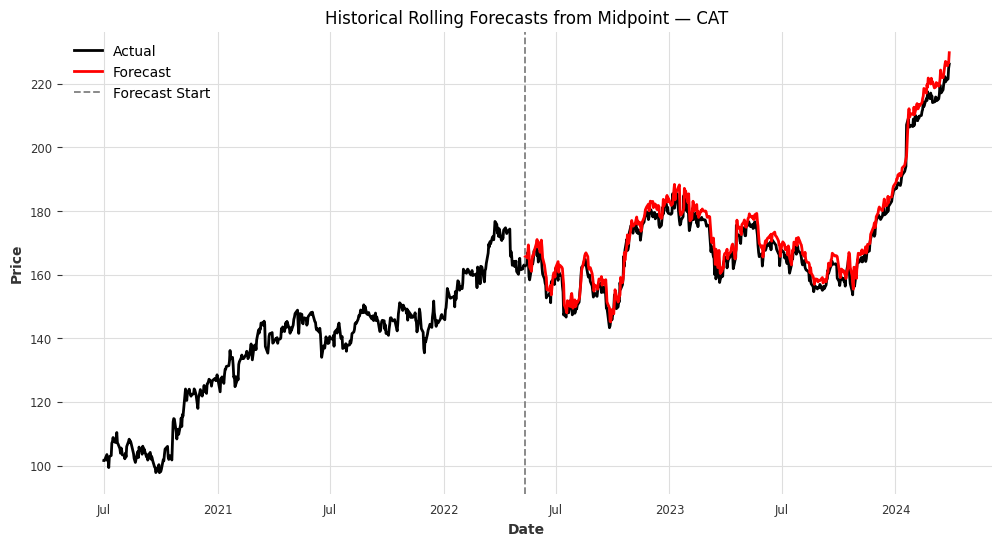

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for CAT: MAPE=1.66%, SMAPE=1.64%, MAE=2.8452, MSE=11.54
Directional Accuracy for CAT: 50.85%



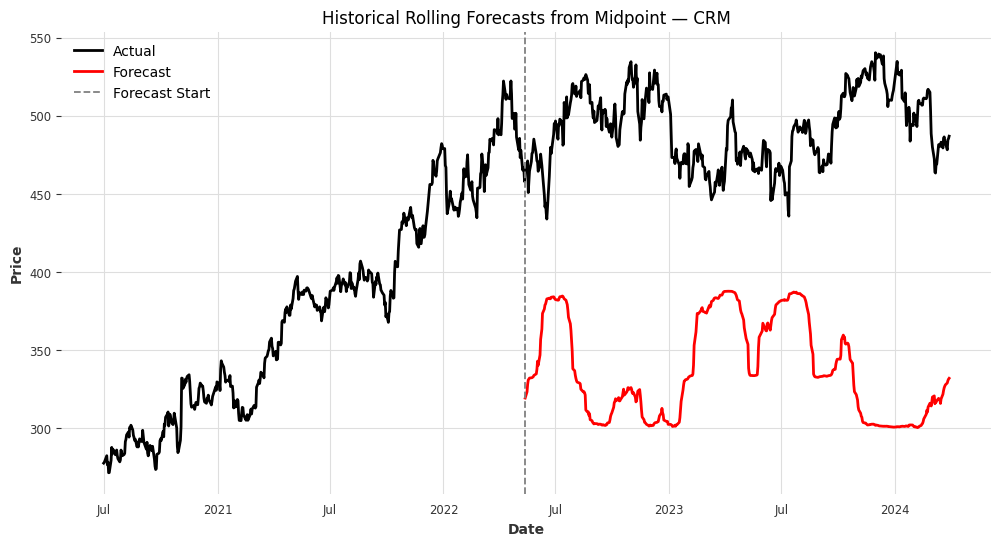

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for CRM: MAPE=31.10%, SMAPE=37.44%, MAE=154.6407, MSE=26263.72
Directional Accuracy for CRM: 50.00%



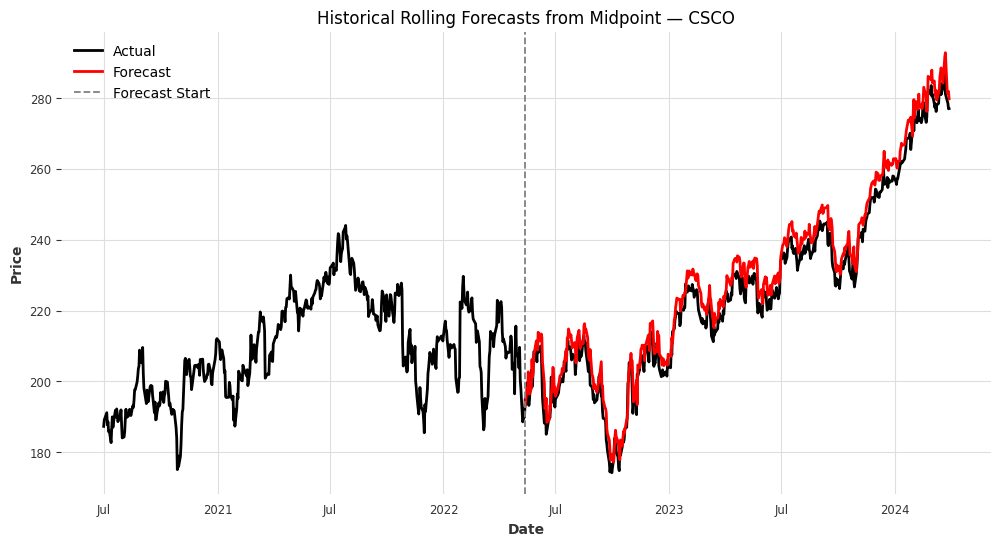

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for CSCO: MAPE=1.79%, SMAPE=1.77%, MAE=4.0028, MSE=21.18
Directional Accuracy for CSCO: 48.09%



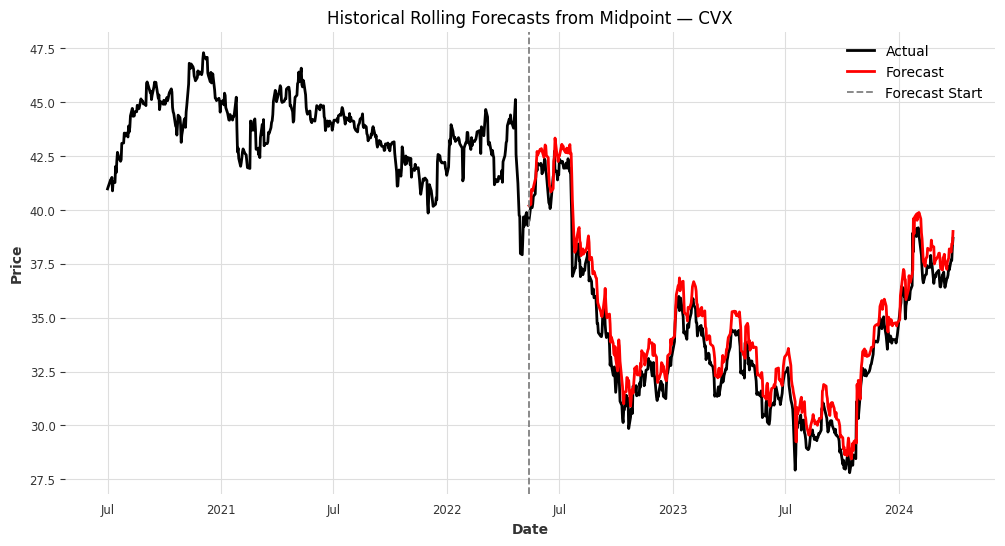

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for CVX: MAPE=2.57%, SMAPE=2.53%, MAE=0.8606, MSE=0.93
Directional Accuracy for CVX: 49.79%



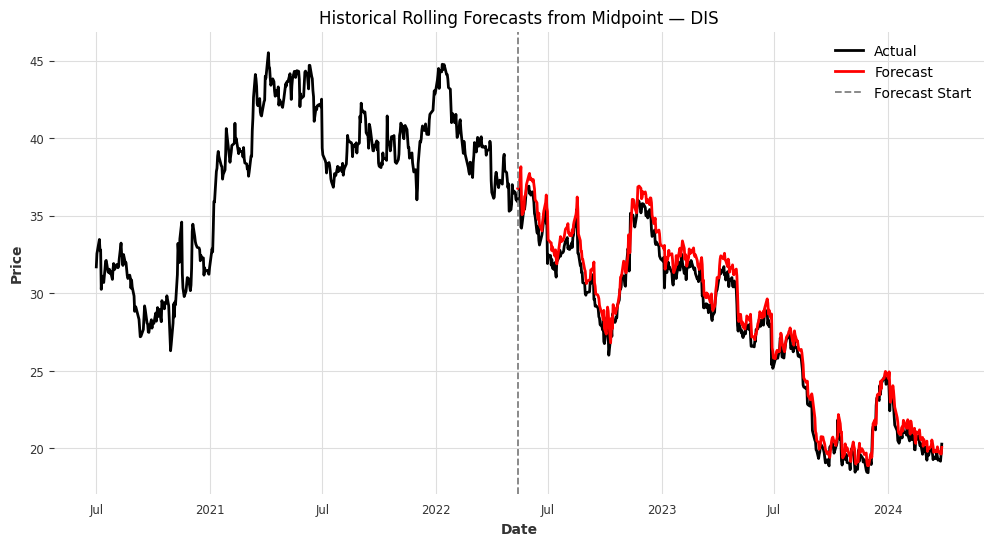

Metrics for DIS: MAPE=2.75%, SMAPE=2.70%, MAE=0.7481, MSE=0.84
Directional Accuracy for DIS: 49.15%

=== Average metrics across all stocks ===
Avg MAE:   2.5954
Avg MSE:   14.71
Avg MAPE:  1.73%
Avg SMAPE: 1.71%
Avg R²:    0.950
Avg Dir Acc: 51.26%


In [27]:
from darts.metrics import mape, smape, mae, mse, r2_score

# real_tickers = ["AMZN","AMGN","AXP","BA","CAT","CRM","CSCO","CVX","DIS","DOW","GS",
#             "HD","HON","IBM","INTC","JNJ","JPM","KO","MCD","MMM","MRK","MSFT",
#             "NKE","PG","TRV","UNH","V","VZ","WBA","WMT"]

real_tickers = ["AMZN", "AMGN","GS","HD","HON","IBM","INTC","JNJ","JPM","KO","MCD","MMM",
                "AXP","MRK","MSFT","NKE","PG","TRV","UNH","V","VZ","WBA","WMT",
                "BA","CAT","CRM","CSCO","CVX","DIS","DOW"]


# exclude = {"GS", "WBA", "UNH", "CRM"} # check if corrupted
exclude = {"CRM"}



# init accumulators
mape_list   = []
smape_list  = []
mae_list    = []
mse_list    = []
r2_list     = []
dir_acc_list = []


def add_symbol_static(ts, sym):
    return ts.with_static_covariates(pd.DataFrame({"symbol": [sym]}))

train_target_list = [
    add_symbol_static(ts, sym)
    for ts, sym in zip(train_target_list, real_tickers)
]
val_target_list = [
    add_symbol_static(ts, sym)
    for ts, sym in zip(val_target_list, real_tickers)
]




# fit scalers on train targets
scaler_dict = {i: Scaler().fit(ts) for i, ts in enumerate(train_target_list)}

symbols = np.array(real_tickers)

for idx, ts_val in enumerate(val_target_list):
    # grab the real symbol name
    symbol = ts_val.static_covariates['symbol'][0]

    # determine start date at midpoint
    mid_idx    = len(ts_val) // 2
    start_date = ts_val.time_index[mid_idx]

    # generate one-step historical forecasts from midpoint to end
    fc_hist = model.historical_forecasts(
        series=ts_val,
        past_covariates=val_past_cov_list[idx],
        start=start_date,
        forecast_horizon=1,
        stride=1,
        retrain=False,
        verbose=False
    )

    # inverse scale
    actual_u = ts_val
    forecast_u = fc_hist

    # plot actual and forecast
    plt.figure(figsize=(12,6))
    actual_u.plot(label='Actual', color='black')
    forecast_u.plot(label='Forecast', color='red')
    plt.axvline(start_date, color='grey', linestyle='--', label='Forecast Start')
    plt.title(f'Historical Rolling Forecasts from Midpoint — {symbols[idx]}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

    # metrics over forecast period
    common     = forecast_u.time_index.intersection(actual_u.time_index)
    actual_sub = actual_u.slice(common[0], common[-1])
    pred_sub   = forecast_u

    mape_val   = mape(actual_sub, pred_sub)
    smape_val  = smape(actual_sub, pred_sub)
    mae_val    = mae(actual_sub, pred_sub)
    mse_val    = mse(actual_sub, pred_sub)
    r2_val     = r2_score(actual_sub, pred_sub)
    print(
        f"Metrics for {symbol}: "
        f"MAPE={mape_val:.2f}%, SMAPE={smape_val:.2f}%, MAE={mae_val:.4f}, MSE={mse_val:.2f}"
    )

    # directional accuracy
    import pandas as _pd
    actual_series   = _pd.Series(actual_u.values().flatten(),   index=actual_u.time_index)
    forecast_series = _pd.Series(forecast_u.values().flatten(), index=forecast_u.time_index)
    common_idx2     = actual_series.index.intersection(forecast_series.index)
    actual_aligned  = actual_series.loc[common_idx2].diff().dropna()
    pred_aligned    = forecast_series.loc[common_idx2].diff().dropna()
    dir_acc         = (actual_aligned * pred_aligned > 0).sum() / len(actual_aligned) * 100
    print(f"Directional Accuracy for {symbol}: {dir_acc:.2f}%\n")

    # append to accumulators
    if symbols[idx] not in exclude:
        mape_list.append(mape_val)
        smape_list.append(smape_val)
        mae_list.append(mae_val)
        mse_list.append(mse_val)
        r2_list.append(r2_val)
        dir_acc_list.append(dir_acc)



# after loop: overall averages
print("=== Average metrics across all stocks ===")
print(f"Avg MAE:   {np.mean(mae_list):.4f}")
print(f"Avg MSE:   {np.mean(mse_list):.2f}")
print(f"Avg MAPE:  {np.mean(mape_list):.2f}%")
print(f"Avg SMAPE: {np.mean(smape_list):.2f}%")
print(f"Avg R²:    {np.mean(r2_list):.3f}")
print(f"Avg Dir Acc: {np.mean(dir_acc_list):.2f}%")

In [29]:
import pandas as pd
import numpy as np
from darts import TimeSeries
from darts.metrics import mae, mape, smape, mse, r2_score

#exclude = {"GS", "WBA", "UNH"} # check if data is corrupted
exclude = {"CRM"}

all_mae, all_mape, all_smape, all_mse, all_r2 = [], [], [], [], []

for idx, ts_val in enumerate(val_target_list):
    symbol = real_tickers[idx]
    if symbol in exclude:
        print(f"— Skipping {symbol}")
        continue

    # 1) one‐step forecasts from midpoint
    fc = model.historical_forecasts(
        series          = ts_val,
        past_covariates = val_past_cov_list[idx],
        start           = ts_val.time_index[len(ts_val)//2],
        forecast_horizon= 1,
        stride          = 1,
        retrain         = False,
        verbose         = False
    )

    # 2) pandas‐align them
    act_pd = pd.Series(ts_val.values().flatten(), index=ts_val.time_index)
    fc_pd  = pd.Series(fc .values().flatten(), index= fc.time_index)
    act2, fc2 = act_pd.align(fc_pd, join="inner")
    if len(act2)==0:
        print(f"⚠️  No overlap for {symbol}, skipping")
        continue

    # 3) rebuild tiny TimeSeries
    actual_sub = TimeSeries.from_times_and_values(act2.index, act2.values)
    pred_sub   = TimeSeries.from_times_and_values(fc2.index,  fc2.values)

    # 4) compute
    m1 = mae(actual_sub, pred_sub)
    m2 = mape(actual_sub, pred_sub)
    m3 = smape(actual_sub, pred_sub)
    m4 = mse(actual_sub, pred_sub)
    r2 = r2_score(actual_sub, pred_sub)

    print(f"\n=== Metrics for {symbol} ===")
    print(f"MAE:   {m1:.4f}")
    print(f"MSE:   {m4:.2f}")
    print(f"MAPE:  {m2:.2f}%")
    print(f"SMAPE: {m3:.2f}%")
    print(f"R²:    {r2:.3f}")

    # 5) accumulate
    all_mae.append(m1)
    all_mape.append(m2)
    all_smape.append(m3)
    all_mse.append(m4)
    all_r2.append(r2)

# 6) overall averages
print("\n=== AVERAGE ACROSS ALL INCLUDED STOCKS ===")
print(f"Avg MAE:   {np.nanmean(all_mae):.4f}")
print(f"Avg MSE:   {np.nanmean(all_mse):.2f}")
print(f"Avg MAPE:  {np.nanmean(all_mape):.2f}%")
print(f"Avg SMAPE: {np.nanmean(all_smape):.2f}%")
print(f"Avg R²:    {np.nanmean(all_r2):.3f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



=== Metrics for AMZN ===
MAE:   2.8009
MSE:   12.09
MAPE:  1.73%
SMAPE: 1.71%
R²:    0.968


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



=== Metrics for AMGN ===
MAE:   4.4335
MSE:   26.81
MAPE:  1.85%
SMAPE: 1.83%
R²:    0.954


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...


=== Metrics for CAT ===
MAE:   2.8452
MSE:   11.54
MAPE:  1.66%
SMAPE: 1.64%
R²:    0.962
— Skipping CRM


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



=== Metrics for CSCO ===
MAE:   4.0028
MSE:   21.18
MAPE:  1.79%
SMAPE: 1.77%
R²:    0.969


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



=== Metrics for CVX ===
MAE:   0.8606
MSE:   0.93
MAPE:  2.57%
SMAPE: 2.53%
R²:    0.928

=== Metrics for DIS ===
MAE:   0.7481
MSE:   0.84
MAPE:  2.75%
SMAPE: 2.70%
R²:    0.972

=== AVERAGE ACROSS ALL INCLUDED STOCKS ===
Avg MAE:   2.5954
Avg MSE:   14.71
Avg MAPE:  1.73%
Avg SMAPE: 1.71%
Avg R²:    0.950


## LoRA Finetuning

In [ ]:
# install peft
!pip install peft

# import and configure LoRA
from peft import LoraConfig, get_peft_model
from darts.models import TFTModel


# build a LoRA config: adapt just the query & value projections
lora_config = LoraConfig(
    r=8,                        # rank of the adapter
    lora_alpha=32,
    target_modules=["q_proj",   # names inside MultiheadAttention
                    "v_proj"],
    bias="none",
    task_type="SEQ_2_SEQ_LM"    # a causal/seq2seq task
)

# wrap the underlying PyTorch model
# TFTModel stores its LightningModule in model.model
peft_model = get_peft_model(model.model, lora_config)

# replace it and retrain—only the LoRA adapters will be updated
model.model = peft_model
model.fit(
    series=train_target_list,
    past_covariates=train_past_cov_list,
    val_series=val_target_list,
    val_past_covariates=val_past_cov_list,
    verbose=True
)


## Save Trained Model

In [ ]:

# torch.save(model.state_dict(), 'multiplex_transformer.pth')


### Next Steps and Integration
- Add an evaluation loop on the validation/test split.
- Export the frozen Transformer to feed the RL environment.
- Experiment with different window/horizon sizes, LoRA ranks, and learning rates.